<a href="https://colab.research.google.com/github/Abdulmajeed-A/Tuwaiq-Linear-Algebra/blob/main/project_linear_algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Import Libraries

In [22]:
# Nawaf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# Step 2: Load Data


In [23]:
# Mohammed
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(path + "/spotify-tracks-dataset.csv",index_col=0)


Using Colab cache for faster access to the 'spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/spotify-tracks-dataset


In [40]:
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  object 
 3   artists           113999 non-null  object 
 4   album_name        113999 non-null  object 
 5   track_name        113999 non-null  object 
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  11

In [41]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [27]:
df.dropna(inplace=True)

In [28]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


# Step 3: Mathematical Focus

AX = λX:


In [29]:
# Mohammed
import sympy as sp

a, b, c, d = sp.symbols('a b c d')
A = sp.Matrix([[a, b],
               [c, d]])
λ = sp.symbols('λ')
x1, x2 = sp.symbols('x1 x2')
X = sp.Matrix([[x1],
               [x2]])
eq = sp.Eq(A@X, λ*X)
print("AX = λX:")
sp.pprint(eq)

AX = λX:
⎡a⋅x₁ + b⋅x₂⎤   ⎡x₁⋅λ⎤
⎢           ⎥ = ⎢    ⎥
⎣c⋅x₁ + d⋅x₂⎦   ⎣x₂⋅λ⎦




```
```

Characteristic equation:

In [30]:
# Mohammed
I = sp.eye(2)
char_eq = A - λ*I
char_eq_det = sp.det(char_eq)
print("\nCharacteristic equation:")
sp.pprint(sp.Eq(char_eq_det, 0))
print('-'*100)


#
A = sp.Matrix([[2, 1],
               [1, 2]])


λ = sp.symbols('λ')
x1, x2 = sp.symbols('x1 x2')
X = sp.Matrix([[x1],
               [x2]])


eq = sp.Eq(A*X, λ*X)
print("AX = λX:")
sp.pprint(eq)


I = sp.eye(2)             #
char_eq = A - λ*I
char_eq_det = sp.det(char_eq)
print("\nCharacteristic equation:")
sp.pprint(sp.Eq(char_eq_det, 0))


eigenvals = sp.solve(char_eq_det, λ)
print("\nEigenvalues (λ):", eigenvals)


for val in eigenvals:
    vecs = (A - val*I).nullspace()
    print(f"\nEigenvector(s) for λ = {val}:")
    sp.pprint(vecs[0])


Characteristic equation:
                         2    
a⋅d - a⋅λ - b⋅c - d⋅λ + λ  = 0
----------------------------------------------------------------------------------------------------
AX = λX:
⎡2⋅x₁ + x₂⎤   ⎡x₁⋅λ⎤
⎢         ⎥ = ⎢    ⎥
⎣x₁ + 2⋅x₂⎦   ⎣x₂⋅λ⎦

Characteristic equation:
 2              
λ  - 4⋅λ + 3 = 0

Eigenvalues (λ): [1, 3]

Eigenvector(s) for λ = 1:
⎡-1⎤
⎢  ⎥
⎣1 ⎦

Eigenvector(s) for λ = 3:
⎡1⎤
⎢ ⎥
⎣1⎦


Eigenvalue interpretation:

In [31]:
# Saad
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(path + "/spotify-tracks-dataset.csv")

# 1: Select chosen features only
features = ['danceability','energy','loudness','speechiness',
            'acousticness','instrumentalness','liveness',
            'valence','tempo','duration_ms']

X = df[features]

# Remove missing values
X = X.dropna()

print("Shape of selected features:", X.shape)
# 2️: Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (should be 0):")
print(np.mean(X_scaled, axis=0))

print("\nStd after scaling (should be 1):")
print(np.std(X_scaled, axis=0))

# 3️: Covariance Matrix
cov_matrix = np.cov(X_scaled.T)

print("Covariance Matrix shape:", cov_matrix.shape)
print("\nCovariance Matrix:\n", cov_matrix)

# 4️: Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Shape of selected features: (114000, 10)
Mean after scaling (should be 0):
[-8.87555137e-16  2.33357193e-16 -1.45598933e-16 -1.31637391e-16
  2.63274782e-16  1.99450592e-18 -2.14908013e-16 -5.58461659e-17
 -2.79230829e-17  2.39340711e-17]

Std after scaling (should be 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Covariance Matrix shape: (10, 10)

Covariance Matrix:
 [[ 1.00000877e+00  1.34326662e-01  2.59079006e-01  1.08627043e-01
  -1.71534836e-01 -1.85607878e-01 -1.31618011e-01  4.77345423e-01
  -5.04503140e-02 -7.34268846e-02]
 [ 1.34326662e-01  1.00000877e+00  7.61696641e-01  1.42510118e-01
  -7.33912759e-01 -1.81880807e-01  1.84797143e-01  2.58936267e-01
   2.47852684e-01  5.85232914e-02]
 [ 2.59079006e-01  7.61696641e-01  1.00000877e+00  6.08268617e-02
  -5.89807841e-01 -4.33480664e-01  7.68993366e-02  2.79850337e-01
   2.12447760e-01 -3.47019561e-03]
 [ 1.08627043e-01  1.42510118e-01  6.08268617e-02  1.00000877e+00
  -2.18635497e-03 -8.96165509e-02  2.05220858e-01  3.66349042e-02
   1.72

Diagonalization:

In [32]:
# Saad
# 4️: Diagonalization

# Matrix P (eigenvectors)
P = eigenvectors

# Diagonal matrix D (eigenvalues)
D = np.diag(eigenvalues)

# Compute P inverse
P_inv = np.linalg.inv(P)

# Reconstruct covariance matrix
C_reconstructed = P @ D @ P_inv

print("Original Covariance Matrix:\n", cov_matrix)
print("\nReconstructed Covariance Matrix (PDP⁻¹):\n", C_reconstructed)

# Check if they are approximately equal
print("\nAre they equal?")
print(np.allclose(cov_matrix, C_reconstructed))

Original Covariance Matrix:
 [[ 1.00000877e+00  1.34326662e-01  2.59079006e-01  1.08627043e-01
  -1.71534836e-01 -1.85607878e-01 -1.31618011e-01  4.77345423e-01
  -5.04503140e-02 -7.34268846e-02]
 [ 1.34326662e-01  1.00000877e+00  7.61696641e-01  1.42510118e-01
  -7.33912759e-01 -1.81880807e-01  1.84797143e-01  2.58936267e-01
   2.47852684e-01  5.85232914e-02]
 [ 2.59079006e-01  7.61696641e-01  1.00000877e+00  6.08268617e-02
  -5.89807841e-01 -4.33480664e-01  7.68993366e-02  2.79850337e-01
   2.12447760e-01 -3.47019561e-03]
 [ 1.08627043e-01  1.42510118e-01  6.08268617e-02  1.00000877e+00
  -2.18635497e-03 -8.96165509e-02  2.05220858e-01  3.66349042e-02
   1.72733749e-02 -6.26003826e-02]
 [-1.71534836e-01 -7.33912759e-01 -5.89807841e-01 -2.18635497e-03
   1.00000877e+00  1.04028032e-01 -2.07005424e-02 -1.07071119e-01
  -2.08225974e-01 -1.03789040e-01]
 [-1.85607878e-01 -1.81880807e-01 -4.33480664e-01 -8.96165509e-02
   1.04028032e-01  1.00000877e+00 -7.98932831e-02 -3.24315173e-01
  -5

# Step 4: AI Connection

Principal Component Analysis (PCA):

In [33]:
# Nawaf
features = df[
[
'danceability',
'energy',
'loudness',
'speechiness',
'acousticness',
'instrumentalness',
'liveness',
'valence',
'tempo'
]
]

# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

pca = PCA(n_components=5)

principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(principal_components, columns=["PC1","PC2","PC3","PC4","PC5"])

print(pca_df.head())

print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))

        PC1       PC2       PC3       PC4       PC5
0  0.639566  1.081838  0.909538 -0.732036 -0.609047
1 -3.331085  1.009646  0.476400  0.244739 -0.852634
2 -1.387507 -0.206667 -0.188111 -0.651474 -1.385974
3 -3.379299 -0.651636 -0.124744  2.892919  0.814322
4 -0.988597  0.255114 -0.469420  0.206115 -0.182612
Explained Variance: [0.31928044 0.15850944 0.13545771 0.10119493 0.09850883]
Total Variance: 0.8129513522565495


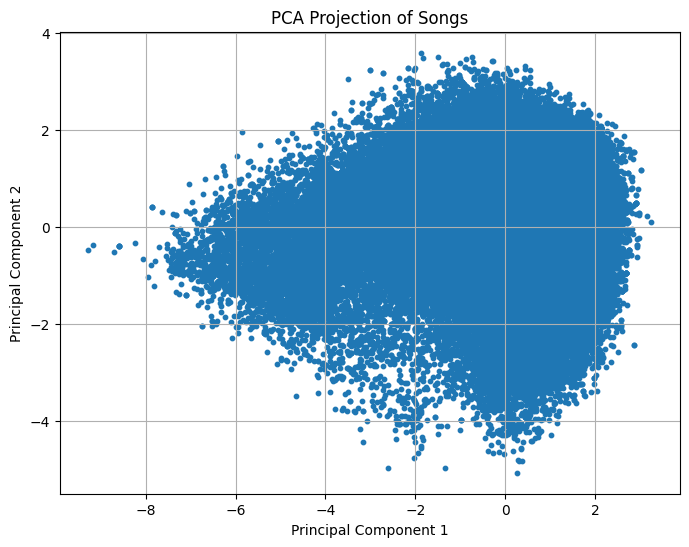

In [34]:
# show it
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=10            # حجم النقطة
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection of Songs")

plt.grid(True)

plt.show()

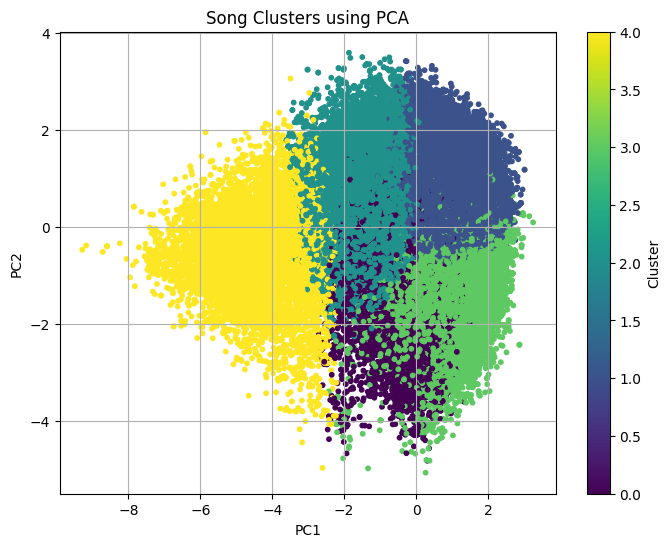

In [35]:
# +add
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)
clusters = kmeans.fit_predict(pca_df)
pca_df["Cluster"] = clusters

# show the result
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",  # ألوان أوضح
    s=10,
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Song Clusters using PCA")

plt.colorbar(label="Cluster")

plt.grid(True)

plt.show()

In [36]:
loadings = pd.DataFrame(
pca.components_.T,
columns=["PC1","PC2","PC3","PC4","PC5"],
index=features.columns
)

print(loadings)

                       PC1       PC2       PC3       PC4       PC5
danceability      0.246124  0.574753 -0.087904 -0.297116  0.251614
energy            0.509169 -0.276668 -0.009551 -0.180374 -0.027754
loudness          0.516955 -0.078893 -0.057596  0.002601 -0.186763
speechiness       0.100642  0.026979  0.641286 -0.248188  0.544183
acousticness     -0.439340  0.296189  0.227287  0.308570  0.027674
instrumentalness -0.282407 -0.305671 -0.201592 -0.496118  0.402401
liveness          0.085137 -0.232589  0.678620  0.089565 -0.250237
valence           0.295023  0.522034  0.021584  0.173990  0.087425
tempo             0.189046 -0.279969 -0.155968  0.661770  0.609877


Principal directions:

In [37]:
# Abdulmajeed

Variance explanation:

In [38]:
# Abdulmajeed

# Step 5: Visualization


In [39]:
# Abdullah